In [21]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

import numpy as np
import json, os, math, glob
import importlib
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output, display

from alvra_tools.utils import *
from alvra_tools.channels import *
from alvra_tools.analysis_apo import *
from alvra_tools.alvra_widgets import Rebin_widget, RunSelectorUI, scan_runs
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

In [95]:
pgroup = 'p23085'
runlist = [159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178]
t0_offsets = [0]*len(runlist)

data, meta = merge_multiple_runs(pgroup, runlist, t0_offset=t0_offsets)

Processing run 159


100%|██████████| 31/31 [00:07<00:00,  4.43it/s]


Processing run 160


100%|██████████| 31/31 [00:07<00:00,  4.43it/s]


Processing run 161


...

100%|██████████| 31/31 [00:07<00:00,  4.30it/s]


Processing run 177


100%|██████████| 31/31 [00:07<00:00,  4.33it/s]


Processing run 178


100%|██████████| 31/31 [00:06<00:00,  4.70it/s]


In [62]:
#plot_merged_data(data, meta, Signal='diode1', Izero='Izero122', TT='124', withTT=True)#, bins=100, figsize=(12, 3))
#plot_merged_data(data, meta, Signal='diode2', Izero='diode1', TT='126', withTT=True)#, bins=100, figsize=(12, 3))

In [96]:
ui, out  = Rebin_widget(data=data)
ui

In [97]:
out["results1"] = Rebin_with_scanvar_and_filter(signal='diode1', data=data, quantile=0.76, izero='Izero122', TT='126', YAGscan=False, withTT=False)
out["results2"] = Rebin_with_scanvar_and_filter(signal='diode2', data=data, quantile=0.76, izero='Izero122', TT='126', YAGscan=False, withTT=False)
out["params"]   = {'signal1': 'diode1', 'signal2': 'diode2', 'izero': 'Izero122', 'quantile': 0.7, 'TT': '126', 'YAGscan': False, 'withTT': False}

Izero122_pump diode1_pump
354866 shots out of 614282 survived
Izero122_pump diode2_pump
355833 shots out of 614282 survived


In [98]:
data_plot1 = {"results": out['results1'], "params": out['params'], "which": "signal1"}
data_plot2 = {"results": out['results2'], "params": out['params'], "which": "signal2"}
#fig, axes = plotter.bins_population(data_plot1, meta)
#fig, axes = plotter.shot_noise(data_plot1, meta)

Data saved in /sf/alvra/data/p23085/work/Reduced_data2/_multiruns/run0159_0160_0161_0162_0163_0164_0165_0166_0167_0168_0169_0170_0171_0172_0173_0174_0175_0176_0177_0178/


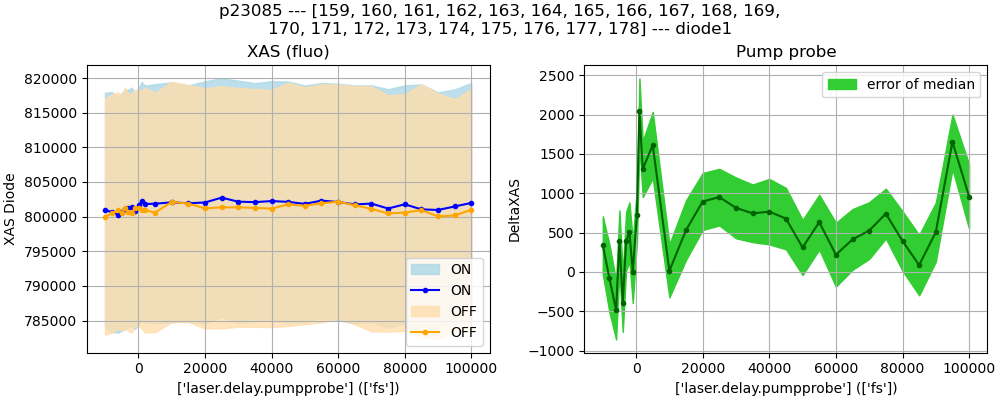

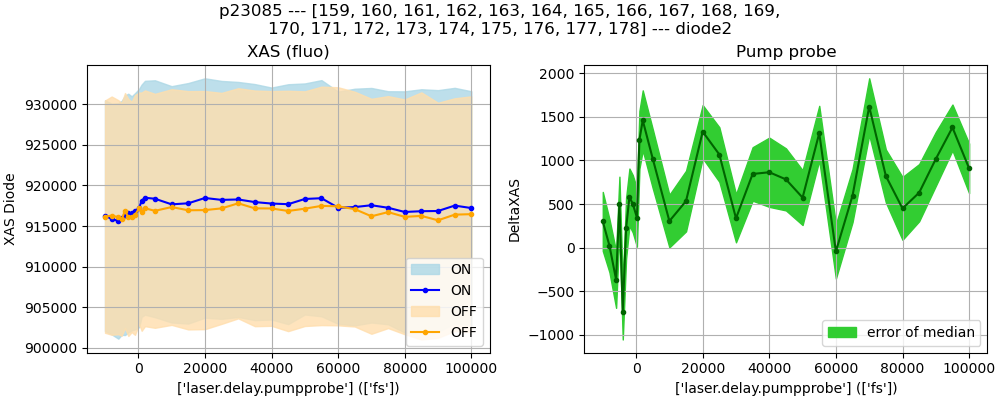

In [99]:
SaveDir = '/sf/alvra/data/{}/work/Reduced_data2/'.format(pgroup)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2)

fig, axes = plotter.delay_scans(data_plot1, meta, errbars=False)
fig, axes = plotter.delay_scans(data_plot2, meta, errbars=False)

Data saved in /sf/alvra/data/p23085/work/Reduced_data2/_multiruns/run0159_0160_0161_0162_0163_0164_0165_0166_0167_0168_0169_0170_0171_0172_0173_0174_0175_0176_0177_0178/


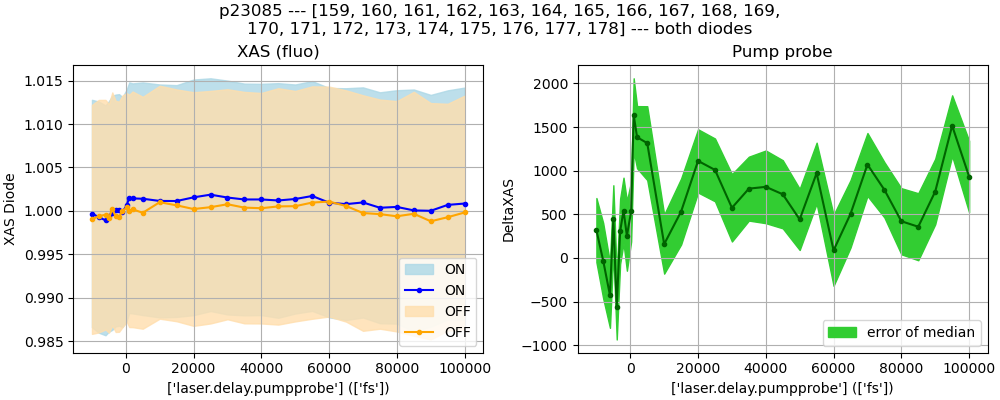

In [100]:
data_plot_both = average_two_diodes(data_plot1, data_plot2)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2, plot_both=data_plot_both)
fig, axes = plotter.delay_scans(data_plot_both, meta, errbars=False)

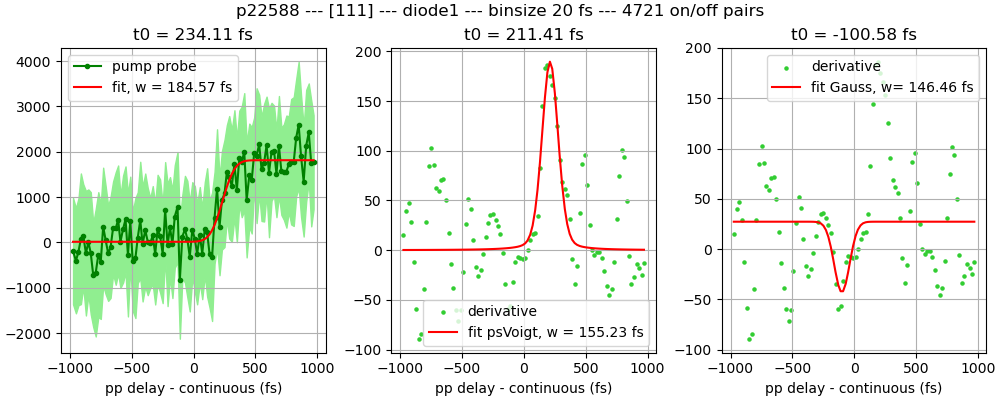

In [15]:
fig, axes = plotter.fit_risetime(data_plot1, meta, fitflag=True)

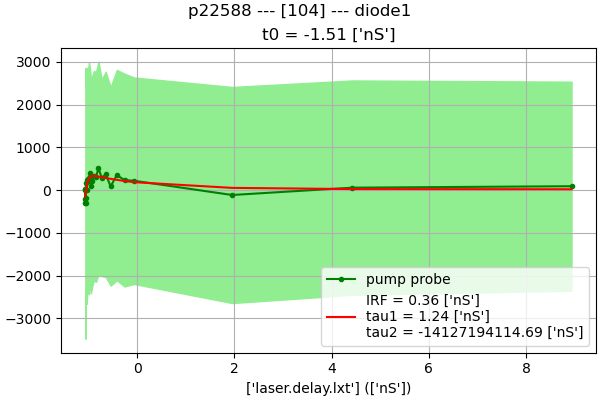

In [24]:

fig, axes = plotter.fit_decay(data_plot1, meta, fitfunction=model_decay_2exp, p0 = [0, 30, 500, 100, 0, 0.01, 1000])

########## model_decay_1exp ##########
###   x0, sigma, amp1, tau1, C
########## model_decay_2exp ##########
###   x0, sigma, amp1, tau1, C, amp2, tau2

# Overlay data with UI

In [42]:
pgroup = 'p22591'
which_plot = 'plot1' #both #plot1

LoadDir = '/sf/alvra/data/{}/work/Reduced_data2/'.format(pgroup)
selector = RunSelectorUI(LoadDir)

Loaded __diode2__ from: /sf/alvra/data/p22591/work/Reduced_data2/_singlerun/run0031/data.npz
Loaded __diode2__ from: /sf/alvra/data/p22591/work/Reduced_data2/_singlerun/run0030/data.npz


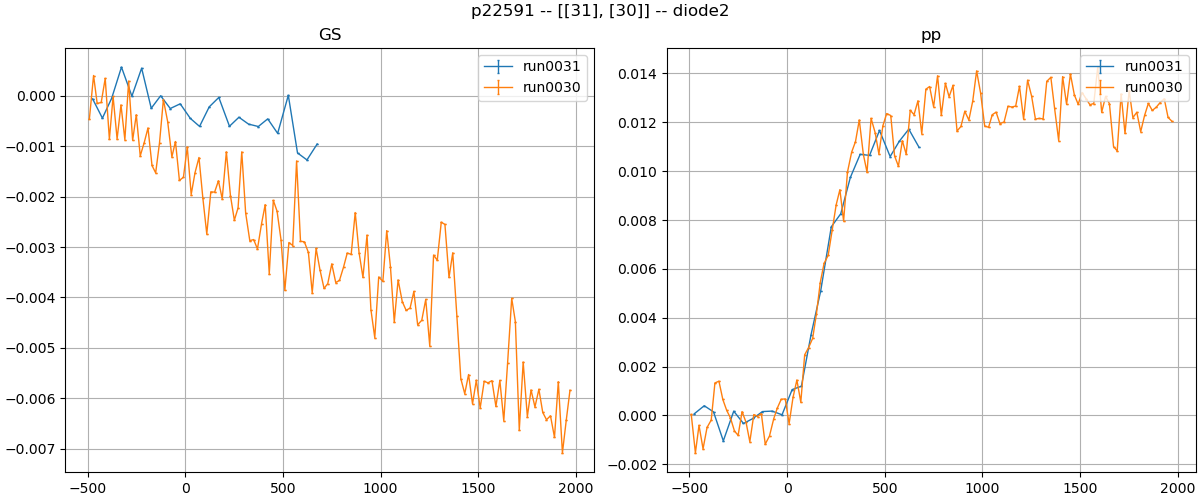

In [45]:
runlist2load = selector.runlist
dataLoaded, runnames, whichdiode = LoadDataAuto(LoadDir, runlist2load, which_plot=which_plot)
fig, ((ax1, ax3)) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for index, dataset in enumerate(dataLoaded):
    label = runnames[index]
    plt.suptitle('{} -- {} -- {}'.format(pgroup, runlist2load, whichdiode))
    d = dataset['results']
    GS = d['GS']
    err_GS = d['err_GS']
    ES = d['ES']
    err_ES = d['err_ES']
    pp = d['pp']
    err_pp = d['err_pp']
    rbk = d['scanvar_rebin']

    ax1.errorbar(rbk, GS - np.mean(GS[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    #ax1.errorbar(rbk, ES- np.mean(ES[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    ax3.errorbar(rbk, pp, 0, lw=1,markersize=0,capsize=1,capthick=1,elinewidth=1, label=label)
ax1.legend(loc = 'upper right')
ax1.grid()
ax1.set_title('GS')
ax3.legend(loc = 'upper right')
ax3.set_title('pp')
ax3.grid()
plt.show()

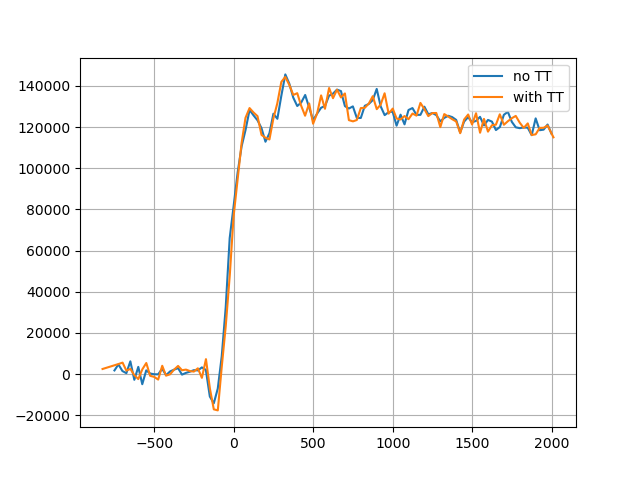

In [27]:
plt.figure()
plt.plot(rbk_noTT, pp_noTT, label = 'no TT')
plt.plot(rbk_withTT, pp_withTT, label = 'with TT')
plt.legend(loc = 'best')
plt.grid()

plt.show()